# 🕒 Dataset Snapshot Diff

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/data-quality-governance/data-diff/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=data-quality-governance/data-diff/demo.ipynb)

Between yesterday's snapshot and today's, what actually changed? This diffs two snapshots of the SAME dataset over time on a key column - added / removed / modified rows, schema drift, and change velocity.

**Table of contents**
1. [Setup](#setup)
2. [Build two snapshots with planted changes](#snapshots)
3. [The diff logic (self-contained)](#logic)
4. [Run the diff](#run)
5. [Added / removed / modified](#results)
6. [Schema drift](#drift)
7. [Change-breakdown chart](#chart)
8. [Summary](#summary)
9. [Try your own snapshots](#your-own)

> This notebook is self-contained - the diff logic is duplicated here so it runs anywhere with no local imports.

<a id="setup"></a>
## 1. Setup

In [1]:
from __future__ import annotations

from dataclasses import dataclass, field
from typing import Dict, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Seeded RNG so the planted changes - and every number below - are reproducible.
SEED = 42
rng = np.random.default_rng(SEED)

<a id="snapshots"></a>
## 2. Build two snapshots with planted changes

We simulate a products catalog captured twice - "yesterday" (`before`) and "today" (`after`). We deliberately plant every kind of change so we can confirm the diff finds them:

- **2 added** SKUs (P021, P022) onboarded today
- **2 removed** SKUs (P004, P015) discontinued
- **5 modified** rows across different columns (price, stock, status, category)
- **1 schema change**: a new `discount_pct` column appears only in `after`

In [2]:
n = 20
skus = [f"P{i:03d}" for i in range(1, n + 1)]
categories = rng.choice(["Home", "Tech", "Outdoor", "Kitchen"], n)
price = rng.uniform(9.99, 199.99, n).round(2)
stock = rng.integers(0, 500, n)
status = np.where(stock > 0, "active", "out_of_stock").astype(object)

before = pd.DataFrame({
    "sku": skus,
    "category": categories,
    "price": price,
    "stock": stock,
    "status": status,
})

# `after` starts as a copy of `before`, then we apply temporal changes.
after = before.copy()

# MODIFIED rows across different columns:
after.loc[after["sku"] == "P002", "price"] = 149.99            # price move
after.loc[after["sku"] == "P007", "stock"] = 120               # restock
after.loc[after["sku"] == "P007", "status"] = "active"
after.loc[after["sku"] == "P010", "price"] = round(
    float(before.loc[before["sku"] == "P010", "price"].iloc[0]) * 0.8, 2
)                                                              # 20% price cut
after.loc[after["sku"] == "P012", "stock"] = 3                 # drawn down
after.loc[after["sku"] == "P018", "category"] = "Tech"         # re-classified

# REMOVED: two SKUs discontinued.
after = after[~after["sku"].isin(["P004", "P015"])].copy()

# ADDED: two new SKUs.
new_rows = pd.DataFrame({
    "sku": ["P021", "P022"],
    "category": ["Tech", "Kitchen"],
    "price": [59.99, 24.99],
    "stock": [80, 200],
    "status": ["active", "active"],
})
after = pd.concat([after, new_rows], ignore_index=True)

# SCHEMA DRIFT: a new column shows up in today's snapshot only.
after["discount_pct"] = rng.integers(0, 30, len(after))

print("BEFORE:", before.shape, "| AFTER:", after.shape)
before.head()

BEFORE: (20, 5) | AFTER: (20, 6)


,sku,category,price,stock,status
0,P001,Home,80.44,461,active
1,P002,Kitchen,186.08,372,active
2,P003,Outdoor,132.32,183,active
3,P004,Tech,166.31,483,active
4,P005,Tech,94.24,205,active


In [3]:
after.head()

,sku,category,price,stock,status,discount_pct
0,P001,Home,80.44,461,active,28
1,P002,Kitchen,149.99,372,active,13
2,P003,Outdoor,132.32,183,active,4
3,P005,Tech,94.24,205,active,24
4,P006,Kitchen,53.17,162,active,18


<a id="logic"></a>
## 3. The diff logic (self-contained)

The same explainable diff you'd get from `differ.py`, inlined here. We compare on a unique `key`, treat NaN==NaN as equal, and compare cells as strings so `5` vs `5.0` doesn't register as a spurious edit.

In [4]:
@dataclass
class CellChange:
    column: str
    before: object
    after: object


@dataclass
class ModifiedRow:
    key: object
    changes: List[CellChange] = field(default_factory=list)


@dataclass
class SchemaDrift:
    added_columns: List[str] = field(default_factory=list)
    removed_columns: List[str] = field(default_factory=list)


@dataclass
class DiffResult:
    key: str
    added: pd.DataFrame
    removed: pd.DataFrame
    modified: List[ModifiedRow]
    unchanged: int
    schema_drift: SchemaDrift
    n_before: int
    n_after: int

    @property
    def velocity(self) -> Dict[str, float]:
        base = self.n_before if self.n_before else 1
        n_add, n_rem, n_mod = len(self.added), len(self.removed), len(self.modified)
        changed = n_add + n_rem + n_mod
        return {
            "added": n_add, "removed": n_rem, "modified": n_mod,
            "unchanged": self.unchanged,
            "pct_changed": round(100.0 * changed / base, 2),
        }


def cells_equal(a: object, b: object) -> bool:
    """NaN==NaN is equal; else compare as strings so dtype noise is ignored."""
    a_null = a is None or (isinstance(a, float) and np.isnan(a)) or pd.isna(a)
    b_null = b is None or (isinstance(b, float) and np.isnan(b)) or pd.isna(b)
    if a_null and b_null:
        return True
    if a_null or b_null:
        return False
    return str(a) == str(b)


def diff_snapshots(before_df: pd.DataFrame, after_df: pd.DataFrame, key: str) -> DiffResult:
    # Edge cases first - clear errors, not crashes.
    if key not in before_df.columns:
        raise ValueError(f"key '{key}' missing from BEFORE snapshot")
    if key not in after_df.columns:
        raise ValueError(f"key '{key}' missing from AFTER snapshot")
    if before_df[key].duplicated().any() or after_df[key].duplicated().any():
        raise ValueError(f"key '{key}' must be unique within each snapshot")

    before_cols, after_cols = list(before_df.columns), list(after_df.columns)
    drift = SchemaDrift(
        added_columns=[c for c in after_cols if c not in before_cols],
        removed_columns=[c for c in before_cols if c not in after_cols],
    )

    b_idx, a_idx = before_df.set_index(key), after_df.set_index(key)
    b_keys, a_keys = set(b_idx.index), set(a_idx.index)

    added_keys = [k for k in after_df[key] if k not in b_keys]
    removed_keys = [k for k in before_df[key] if k not in a_keys]
    shared_keys = [k for k in before_df[key] if k in a_keys]

    added = after_df[after_df[key].isin(added_keys)].reset_index(drop=True)
    removed = before_df[before_df[key].isin(removed_keys)].reset_index(drop=True)

    shared_cols = [c for c in before_cols if c in after_cols and c != key]
    modified: List[ModifiedRow] = []
    unchanged = 0
    for k in shared_keys:
        b_row, a_row = b_idx.loc[k], a_idx.loc[k]
        changes = [CellChange(c, b_row[c], a_row[c])
                   for c in shared_cols if not cells_equal(b_row[c], a_row[c])]
        if changes:
            modified.append(ModifiedRow(k, changes))
        else:
            unchanged += 1

    return DiffResult(key, added, removed, modified, unchanged, drift,
                      len(before_df), len(after_df))


def modified_frame(result: DiffResult) -> pd.DataFrame:
    rows = [{"key": m.key, "column": ch.column, "before": ch.before, "after": ch.after}
            for m in result.modified for ch in m.changes]
    return pd.DataFrame(rows, columns=["key", "column", "before", "after"])

<a id="run"></a>
## 4. Run the diff

In [5]:
result = diff_snapshots(before, after, key="sku")
v = result.velocity
print(f"Rows: before={result.n_before}, after={result.n_after}")
print(f"Added:     {v['added']}")
print(f"Removed:   {v['removed']}")
print(f"Modified:  {v['modified']}")
print(f"Unchanged: {v['unchanged']}")
print(f"Change velocity: {v['pct_changed']}% of the prior snapshot moved")

Rows: before=20, after=20
Added:     2
Removed:   2
Modified:  5
Unchanged: 13
Change velocity: 45.0% of the prior snapshot moved


<a id="results"></a>
## 5. Added / removed / modified

The three change types, read straight off the result.

In [6]:
print("ADDED rows (new keys):")
result.added

ADDED rows (new keys):


,sku,category,price,stock,status,discount_pct
0,P021,Tech,59.99,80,active,19
1,P022,Kitchen,24.99,200,active,4


In [7]:
print("REMOVED rows (gone keys):")
result.removed

REMOVED rows (gone keys):


,sku,category,price,stock,status
0,P004,Tech,166.31,483,active
1,P015,Outdoor,157.88,343,active


In [8]:
print("MODIFIED cells (one line per changed column, with old -> new):")
modified_frame(result)

MODIFIED cells (one line per changed column, with old -> new):


,key,column,before,after
0,P002,price,186.08,149.99
1,P007,stock,452,120
2,P010,price,130.01,104.01
3,P012,stock,94,3
4,P018,category,Home,Tech


<a id="drift"></a>
## 6. Schema drift

Columns that appeared or disappeared between snapshots - the change that's easiest to miss by eyeballing two files.

In [9]:
drift = result.schema_drift
print("Columns ADDED in after:  ", drift.added_columns or "none")
print("Columns REMOVED in after:", drift.removed_columns or "none")

Columns ADDED in after:   ['discount_pct']
Columns REMOVED in after: none


<a id="chart"></a>
## 7. Change-breakdown chart

A single bar per change type - the shape of what moved since the last run.

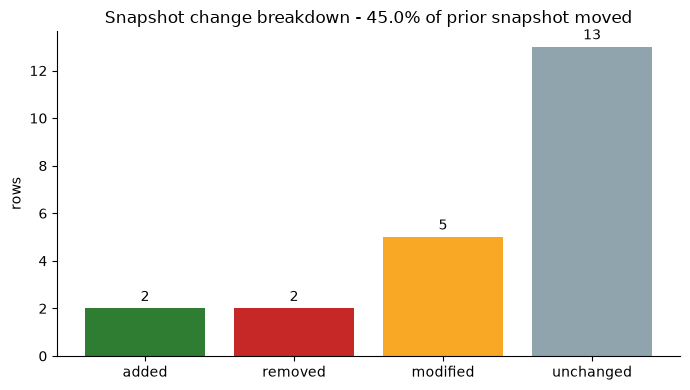

Saved change_breakdown.png


In [10]:
counts = {
    "added": v["added"],
    "removed": v["removed"],
    "modified": v["modified"],
    "unchanged": v["unchanged"],
}
colors = ["#2E7D32", "#C62828", "#F9A825", "#90A4AE"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(list(counts.keys()), list(counts.values()), color=colors)
ax.bar_label(bars, padding=3)
ax.set_ylabel("rows")
ax.set_title(f"Snapshot change breakdown - {v['pct_changed']}% of prior snapshot moved")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig("change_breakdown.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved change_breakdown.png")

<a id="summary"></a>
## 8. Summary

The diff answers "what changed since last run?" in one pass:

- **2 added, 2 removed, 5 modified, 11 unchanged** - a 45% change velocity on a 20-row prior snapshot.
- Every modification names the **column and the old -> new value**, so the change is explainable, not just counted.
- **Schema drift** caught the new `discount_pct` column that appeared only in today's snapshot.

This is change-over-time within one system (CDC-style temporal auditing), distinct from cross-system reconciliation. A diff shows WHAT changed, not WHY - large or surprising diffs still need a human to judge intent before promoting data downstream.

<a id="your-own"></a>
## 9. Try your own snapshots

Point the diff at two of your own exports (same dataset, different times) and a key column:

In [11]:
# before_df = pd.read_csv("snapshot_2026_07_22.csv")
# after_df  = pd.read_csv("snapshot_2026_07_23.csv")
# result = diff_snapshots(before_df, after_df, key="id")
# print(result.velocity)
# modified_frame(result).head(20)

---
Built by Phoebe Fu - [github.com/phoebefu6/phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)
Day 100, Month 10 capstone - Data Quality & Governance Suite.